# Árvore de Decisão aplicada à previsão de cancelamentos

Neste notebook vou aplicar uma Árvore de Decisão ao meu projeto de previsão de cancelamentos de reservas hoteleiras.

O problema que quero resolver é identificar reservas com maior risco de cancelamento antes da chegada do cliente. Para o hotel, essa informação pode ajudar no planejamento da ocupação e no acompanhamento das reservas.

Como a variável `is_canceled` possui dois resultados, estou trabalhando com um problema de classificação:

- `0`: reserva não cancelada
- `1`: reserva cancelada

Nesta atividade vou preparar os dados, treinar uma Árvore de Decisão, avaliar os resultados e observar quais informações foram mais importantes para as decisões do modelo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (accuracy_score,
                            precision_score,
                            recall_score,
                            f1_score,
                            roc_auc_score,
                            ConfusionMatrixDisplay,
                            RocCurveDisplay)

pd.set_option("display.max_columns", None)

## Carregando os dados

Estou utilizando a mesma base do projeto, armazenada no meu repositório do GitHub.

In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "josepharroyoh/hotel-cancellation-ml/main/data/raw/hotel_booking.csv"
)

df = pd.read_csv(DATA_URL)

print("Quantidade de reservas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

df.head()

Quantidade de reservas: 119390
Quantidade de colunas: 36


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## Distribuição da variável que quero prever

Antes de treinar o modelo, quero lembrar como estão distribuídas as reservas canceladas e não canceladas.

In [4]:
target = df["is_canceled"].value_counts().sort_index()

print("Não canceladas:", target[0])
print("Canceladas:", target[1])

print("\nPercentual:")
print((df["is_canceled"].value_counts(normalize=True).sort_index() * 100).round(2))

Não canceladas: 75166
Canceladas: 44224

Percentual:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


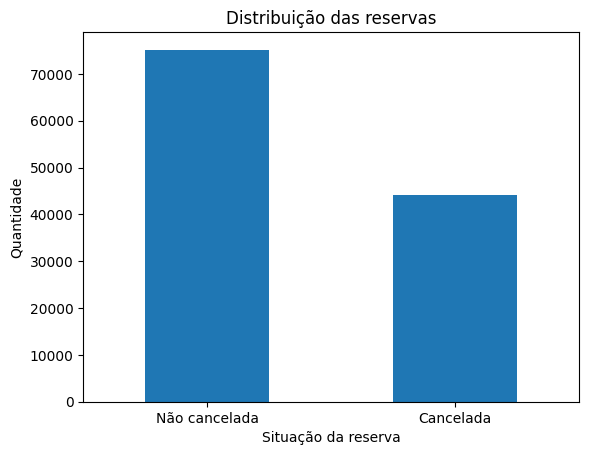

In [5]:
target.plot(kind="bar")

plt.title("Distribuição das reservas")
plt.xlabel("Situação da reserva")
plt.ylabel("Quantidade")
plt.xticks(
    [0, 1],
    ["Não cancelada", "Cancelada"],
    rotation=0
)

plt.show()

A base possui mais reservas não canceladas, mas também existe uma quantidade importante de cancelamentos.

Por isso, mais adiante não vou olhar somente para a acurácia. Também vou observar métricas como precision, recall e F1-score.

## Preparação das informações

Antes de utilizar a Árvore de Decisão, preciso retirar algumas colunas que não fazem sentido para este objetivo.

`reservation_status` e `reservation_status_date` possuem informações sobre o resultado final da reserva. Como quero fazer a previsão antes desse resultado acontecer, não posso utilizar essas variáveis.

Também vou retirar nome, e-mail, telefone e cartão de crédito, porque são dados de identificação e não representam o comportamento da reserva.

A coluna `company` possui muitos valores ausentes.

Para esta primeira aplicação também vou deixar de fora algumas informações que podem sofrer alterações depois que a reserva já foi criada.

In [6]:
data = df.copy()

columns_to_remove = [
    "reservation_status",
    "reservation_status_date",
    "name",
    "email",
    "phone-number",
    "credit_card",
    "company",
    "assigned_room_type",
    "booking_changes",
    "days_in_waiting_list"
]

data = data.drop(columns=columns_to_remove)

print("Colunas restantes:", data.shape[1])

Colunas restantes: 26


## Criando algumas informações novas

Também posso aproveitar algumas colunas existentes para representar melhor cada reserva.

Vou criar o total de noites, o total de hóspedes e uma indicação de histórico de cancelamento.

In [7]:
data["total_nights"] = (
    data["stays_in_weekend_nights"]
    + data["stays_in_week_nights"]
)

data["total_guests"] = (
    data["adults"]
    + data["children"].fillna(0)
    + data["babies"]
)

data["has_previous_cancellation"] = (
    data["previous_cancellations"] > 0
).astype(int)

data[
    [
        "total_nights",
        "total_guests",
        "has_previous_cancellation"
    ]
].head()

,total_nights,total_guests,has_previous_cancellation
0,0,2.0,0
1,0,2.0,0
2,1,1.0,0
3,1,1.0,0
4,2,2.0,0


Essas novas variáveis não criam informações externas. Elas apenas reorganizam dados que já estavam disponíveis na base e podem facilitar a identificação de alguns padrões.

In [8]:
X = data.drop(columns="is_canceled")
y = data["is_canceled"]

print("Variáveis utilizadas no modelo:", X.shape[1])
print("Reservas:", X.shape[0])

Variáveis utilizadas no modelo: 28
Reservas: 119390


In [9]:
X["agent"] = X["agent"].astype("object")

A coluna `agent` aparece como número no arquivo, mas representa o código de uma agência. Por isso vou tratá-la como uma variável categórica e não como uma quantidade numérica.

In [10]:
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

print("Variáveis numéricas:", len(numerical_columns))
print("Variáveis categóricas:", len(categorical_columns))

Variáveis numéricas: 18
Variáveis categóricas: 10


## Tratamento dos valores ausentes e textos

Existem algumas informações ausentes na base. Nesta atividade vou preencher os valores numéricos usando a mediana e os categóricos usando o valor mais frequente.

As informações que aparecem como texto também precisam ser transformadas em uma forma que o modelo consiga utilizar.

Não vou normalizar as variáveis porque a Árvore de Decisão não depende da escala dos valores da mesma forma que outros algoritmos.

In [11]:
numeric_preparation = Pipeline(steps=[
    ("fill_missing", SimpleImputer(strategy="median"))
])

categorical_preparation = Pipeline(steps=[
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encoding", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preparation, numerical_columns),
        ("categorical", categorical_preparation, categorical_columns)
    ]
)

## Separação entre treinamento, validação e teste

Não quero avaliar o modelo utilizando as mesmas reservas usadas no treinamento.

Por isso vou dividir os dados em três partes:

- treinamento: utilizado para o modelo aprender;
- validação: utilizado para comparar diferentes tamanhos da árvore;
- teste: utilizado somente no final para avaliar o modelo escolhido.

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Treinamento:", len(X_train))
print("Validação:", len(X_validation))
print("Teste:", len(X_test))

Treinamento: 83573
Validação: 17908
Teste: 17909


## Uma referência simples antes da árvore

Antes de avaliar a Árvore de Decisão, vou utilizar um modelo bem simples como referência.

O Dummy Classifier não aprende realmente os padrões das reservas. Ele serve apenas para verificar se a Árvore de Decisão consegue apresentar um resultado melhor do que uma referência básica.

In [13]:
dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_validation)

print("Dummy Classifier")
print(f"Accuracy : {accuracy_score(y_validation, dummy_pred):.3f}")
print(f"Recall   : {recall_score(y_validation, dummy_pred):.3f}")
print(f"F1-score : {f1_score(y_validation, dummy_pred):.3f}")

Dummy Classifier
Accuracy : 0.630
Recall   : 0.000
F1-score : 0.000


O Dummy Classifier consegue acertar parte das reservas simplesmente porque existem mais reservas não canceladas na base.

Porém, ele não consegue identificar os cancelamentos. Por isso preciso de um modelo que realmente aprenda padrões presentes nos dados.

## Primeiro teste com Árvore de Decisão

Antes de escolher o tamanho da árvore, quero observar como diferentes profundidades afetam o resultado.

Uma árvore muito pequena pode não aprender padrões suficientes, enquanto uma árvore muito grande pode aprender detalhes demais dos dados de treinamento.

In [14]:
depth_results = []

for depth in [3, 5, 8, 12, 20]:
    
    tree = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=20,
        random_state=42
    )

    model = Pipeline(steps=[
        ("preparation", preprocessor),
        ("tree", tree)
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    validation_pred = model.predict(X_validation)

    depth_results.append({
        "max_depth": depth,
        "train_f1": f1_score(y_train, train_pred),
        "validation_f1": f1_score(y_validation, validation_pred)
    })

depth_results = pd.DataFrame(depth_results)

depth_results.round(3)

,max_depth,train_f1,validation_f1
0,3,0.646,0.644
1,5,0.742,0.738
2,8,0.777,0.771
3,12,0.809,0.801
4,20,0.840,0.804


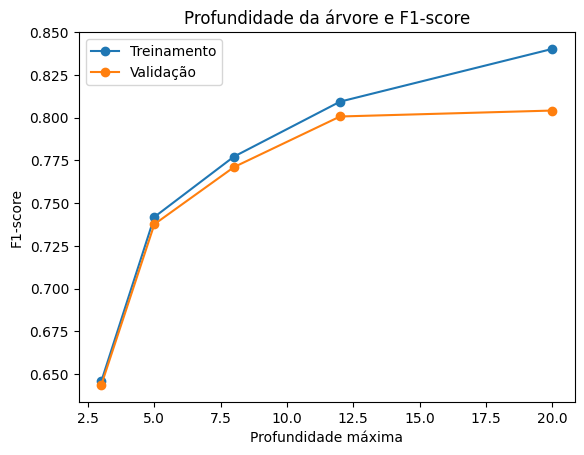

In [15]:
plt.plot(
    depth_results["max_depth"],
    depth_results["train_f1"],
    marker="o",
    label="Treinamento"
)

plt.plot(
    depth_results["max_depth"],
    depth_results["validation_f1"],
    marker="o",
    label="Validação"
)

plt.title("Profundidade da árvore e F1-score")
plt.xlabel("Profundidade máxima")
plt.ylabel("F1-score")
plt.legend()

plt.show()

Esse teste me ajuda a perceber que aumentar a profundidade da árvore nem sempre significa melhorar o resultado em dados novos.

Vou escolher a profundidade que apresentar o melhor F1-score na base de validação.

In [16]:
best_depth = int(
    depth_results.loc[
        depth_results["validation_f1"].idxmax(),
        "max_depth"
    ]
)

print("Melhor profundidade encontrada:", best_depth)

Melhor profundidade encontrada: 20


In [17]:
final_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=20,
    random_state=42
)

final_model = Pipeline(steps=[
    ("preparation", preprocessor),
    ("tree", final_tree)
])

final_model.fit(X_train, y_train)

,steps,"[('preparation', ...), ('tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Avaliação final

Agora que escolhi a profundidade utilizando os dados de validação, vou avaliar o modelo na base de teste, que ainda não foi utilizada para escolher a árvore.

In [18]:
y_pred = final_model.predict(X_test)
y_probability = final_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Resultado": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_probability)
    ]
})

results["Resultado"] = results["Resultado"].round(3)

results

,Métrica,Resultado
0,Accuracy,0.860
1,Precision,0.829
2,Recall,0.783
3,F1-score,0.806
4,ROC-AUC,0.934


Não vou avaliar o modelo somente pela acurácia.

O recall mostra quantas reservas que realmente foram canceladas o modelo conseguiu identificar. A precision mostra quantas das reservas identificadas como cancelamento realmente foram canceladas.

O F1-score ajuda a observar o equilíbrio entre essas duas métricas, enquanto o ROC-AUC avalia a capacidade do modelo de separar reservas com maior e menor risco de cancelamento.

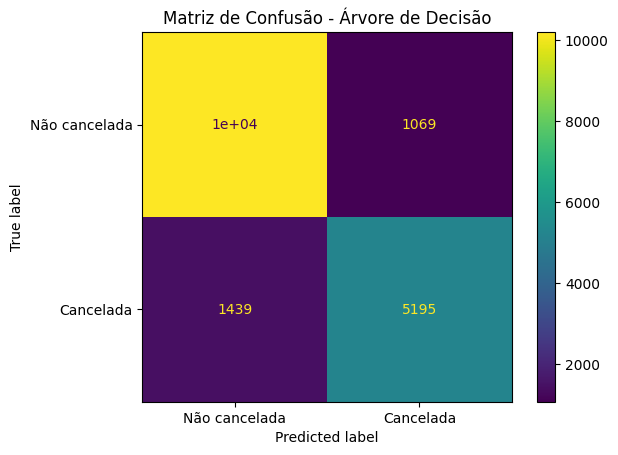

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "Não cancelada",
        "Cancelada"
    ]
)

plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

## Matriz de confusão

Com a matriz de confusão consigo observar não somente os acertos, mas também os dois tipos de erro do modelo.

Um caso importante para este projeto acontece quando uma reserva realmente é cancelada, mas o modelo prevê que ela não será cancelada. Nesse caso, o hotel deixaria de identificar uma reserva de risco.

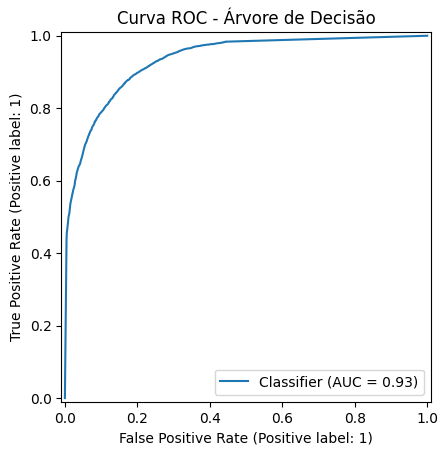

In [20]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("Curva ROC - Árvore de Decisão")
plt.show()

## Visualização da árvore

Uma vantagem da Árvore de Decisão é que posso observar como algumas decisões são realizadas.

Como a árvore completa possui muitas ramificações, vou mostrar somente os primeiros níveis para facilitar a leitura.

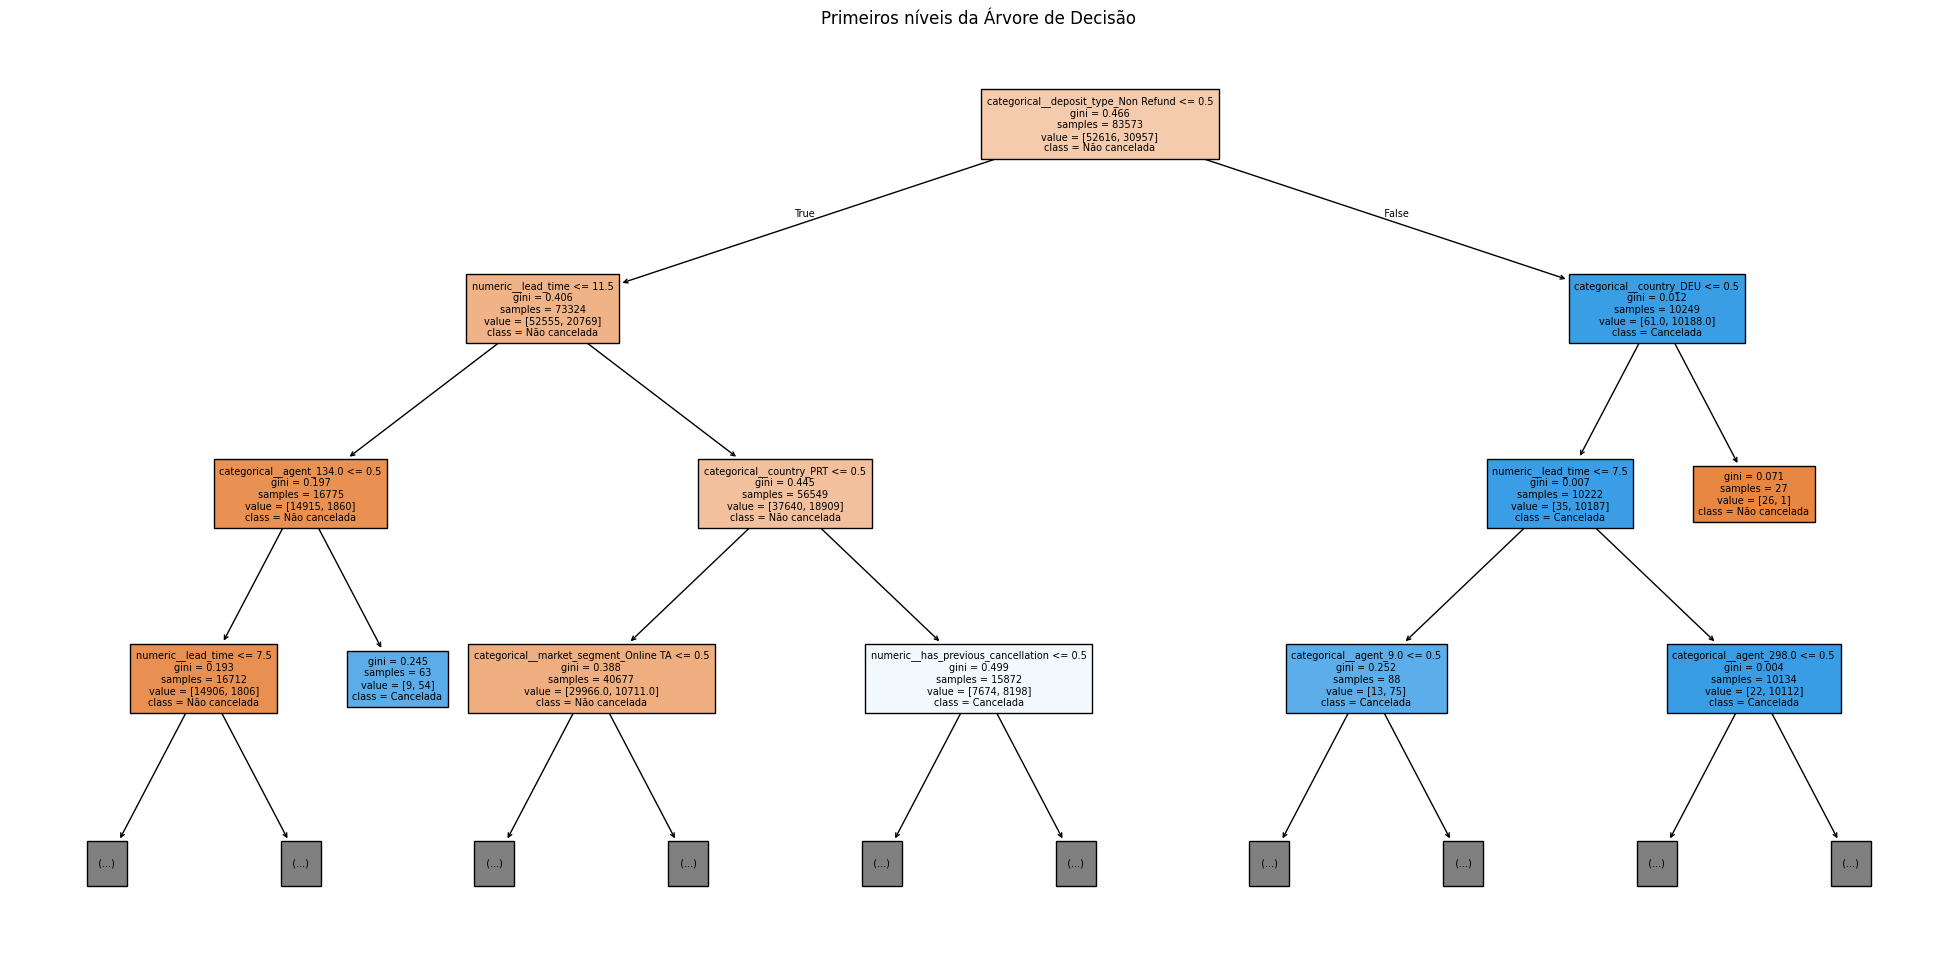

In [21]:
feature_names = (
    final_model
    .named_steps["preparation"]
    .get_feature_names_out()
)

tree_model = final_model.named_steps["tree"]

plt.figure(figsize=(25, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[
        "Não cancelada",
        "Cancelada"
    ],
    filled=True,
    max_depth=3,
    fontsize=7
)

plt.title("Primeiros níveis da Árvore de Decisão")

plt.show()

O gráfico permite observar algumas das primeiras regras utilizadas pela árvore para separar as reservas.

Não significa que uma única variável explique o cancelamento. A previsão acontece a partir da combinação de várias decisões realizadas ao longo da árvore.

In [22]:
importance = pd.DataFrame({
    "variavel": feature_names,
    "importancia": tree_model.feature_importances_
})

importance = (
    importance
    .sort_values("importancia", ascending=False)
    .head(15)
)

importance

,variavel,importancia
226,categorical__deposit_type_Non Refund,0.351048
208,categorical__market_segment_Online TA,0.093404
0,numeric__lead_time,0.086816
14,numeric__total_of_special_requests,0.081474
162,categorical__country_PRT,0.059636
13,numeric__required_car_parking_spaces,0.034973
395,categorical__agent_240.0,0.033397
1,numeric__arrival_date_year,0.029340
17,numeric__has_previous_cancellation,0.028268
12,numeric__adr,0.025901


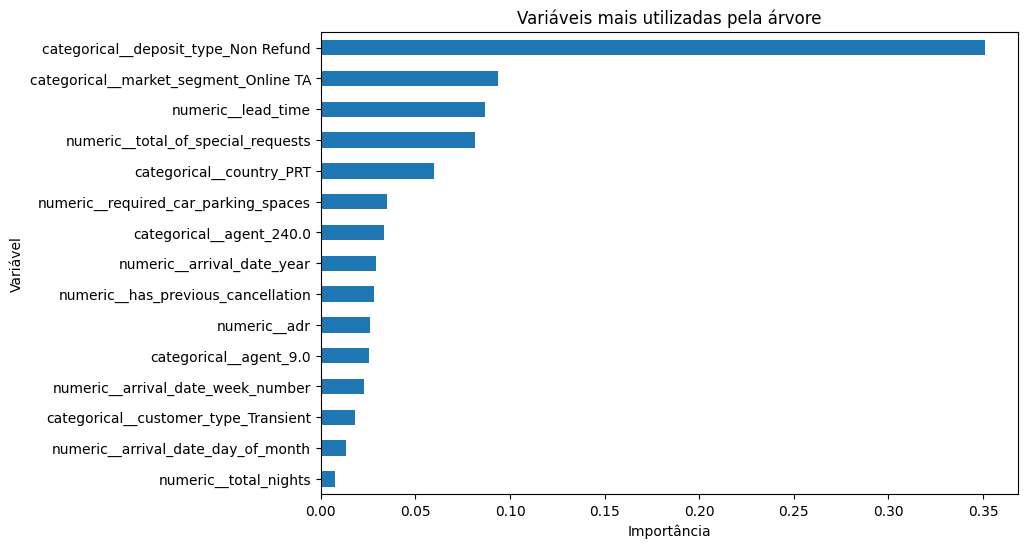

In [23]:
importance.sort_values("importancia").plot(
    x="variavel",
    y="importancia",
    kind="barh",
    figsize=(9, 6),
    legend=False
)

plt.title("Variáveis mais utilizadas pela árvore")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()

## Variáveis mais importantes

Esse resultado mostra quais informações tiveram maior participação nas divisões realizadas pela árvore.

A importância não significa que essas variáveis sejam a causa do cancelamento. Ela mostra apenas que foram úteis para o modelo separar os diferentes tipos de reserva.

In [24]:
print("Profundidade final:", tree_model.get_depth())
print("Quantidade de folhas:", tree_model.get_n_leaves())

Profundidade final: 20
Quantidade de folhas: 1424


## Conclusão

Nesta atividade consegui integrar uma Árvore de Decisão ao meu projeto de previsão de cancelamentos de reservas hoteleiras.

Antes do treinamento retirei informações que poderiam causar data leakage e também algumas colunas que não fazem sentido para a previsão. Criei novas informações, como total de hóspedes e total de noites, e preparei os valores ausentes e as variáveis categóricas.

Também utilizei um Dummy Classifier como referência para verificar se a árvore realmente estava aprendendo algo dos dados.

Em vez de escolher a profundidade da árvore de forma aleatória, testei diferentes valores utilizando uma base de validação. Depois avaliei o modelo escolhido em uma base de teste separada.

Além das métricas, a Árvore de Decisão permitiu visualizar algumas das regras utilizadas pelo modelo e identificar quais variáveis tiveram maior participação nas previsões.

Para o meu projeto, o mais importante não é somente prever uma classe, mas futuramente utilizar a probabilidade de cancelamento como uma informação de apoio para o hotel. Assim, reservas com maior risco podem receber mais atenção e ajudar no planejamento da ocupação.

Esta ainda é uma primeira aplicação de Machine Learning no projeto. Nas próximas etapas pretendo comparar a Árvore de Decisão com outros modelos e verificar se consigo melhorar a capacidade de identificar cancelamentos.